<a href="https://colab.research.google.com/github/EmePin/Analisis-de-datos/blob/main/An%C3%A1lisis_y_predicci%C3%B3n_de_VM_Futbolistas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje Supervisado

Este cuaderno se centra en la aplicación de técnicas de aprendizaje supervisado dentro del ámbito del análisis de datos para comprender en profundidad las variables que influyen en el valor de mercado de los futbolistas y en la construcción de un modelo predictivo capaz de estimar con precisión el precio de los jugadores. A través de este análisis, utilizando herramientas como pandas para la manipulación y análisis de datos tabulares, seaborn y matplotlib.pyplot para la visualización informativa, y plotly para la creación de gráficos interactivos, buscamos identificar los factores clave que impulsan las valoraciones en el mercado de fichajes. El objetivo final es proporcionar una herramienta útil para la toma de decisiones basada en predicciones precisas, dirigida a clubes, agencias y otras partes interesadas en la industria del fútbol, evaluando el rendimiento del modelo mediante métricas como el error cuadrático medio (mean_squared_error) y el coeficiente de determinación (r2_score), tal como se aplica en la predicción con algoritmos como RandomForestRegressor del sklearn.ensemble.

##Extracción de datos

In [77]:
# se monta el contenido del drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
# Lee el archivo CSV
df = pd.read_excel('/content/drive/MyDrive/COLAB_BD/BD_Futbolistas/futbolistas.xlsx')

## Análisis exploratorio de datos (EDA)

In [80]:
# Muestra (number_of_rows, number_of_columns).
df.shape

(400, 13)

In [81]:
# Muestra las primeras filas del DataFrame
df.head()

,Id,Nombre,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Gimnasio,Fuma,Nacimiento,Nutriólogo,Horas_Casa
0,1,Mario Llanos,1,4,6,1.691695,4.711956e+05,12,No,Si,1998-01-25,Si,8
1,2,Marta Nathal,1,6,6,1.649811,7.872461e+05,12,Si,No,1998-01-23,Si,8
2,3,Howard Sierra,1,5,13,1.835804,1.795484e+06,10,Si,No,1998-01-24,Si,9
3,4,Luna Nava,1,3,9,1.675274,9.755637e+05,12,Si,No,1998-01-08,No,5
4,5,Eugenio Ibarra,1,3,5,1.597647,4.048235e+05,9,Si,No,1998-01-20,Si,5


In [82]:
df.nunique()

,0
Id,400
Nombre,399
Liga,4
Prácticas,9
Horas_Entrenando,21
Altura,400
Precio,369
Juegos,12
Gimnasio,2
Fuma,2


In [83]:
conteo_nombres = df['Nombre'].value_counts()
conteo_nombres

,count
Nombre,
Ángel Varela,2
Alex Lacy,1
Abril Tamayo,1
Emmelyn Marín,1
Asfand Vega,1
...,...
Nelson Montalvo,1
Reinaldo Funes,1
Rubén Alva,1


In [84]:
# la info donde nombre sea Ángel Varela

df[df['Nombre'] == 'Ángel Varela']


,Id,Nombre,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Gimnasio,Fuma,Nacimiento,Nutriólogo,Horas_Casa
23,24,Ángel Varela,1,8,11,1.424211,946268.493039,10,Si,No,1998-01-05,No,7
52,53,Ángel Varela,1,5,14,1.707449,842253.775592,8,Si,No,1998-02-06,Si,3


In [85]:
# Veamos las variables categóricas y las numéricas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Id                400 non-null    int64         
 1   Nombre            400 non-null    object        
 2   Liga              400 non-null    int64         
 3   Prácticas         400 non-null    int64         
 4   Horas_Entrenando  400 non-null    int64         
 5   Altura            400 non-null    float64       
 6   Precio            400 non-null    float64       
 7   Juegos            400 non-null    int64         
 8   Gimnasio          400 non-null    object        
 9   Fuma              400 non-null    object        
 10  Nacimiento        400 non-null    datetime64[ns]
 11  Nutriólogo        400 non-null    object        
 12  Horas_Casa        400 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(4)
memory usage: 40.8+ KB


In [86]:
df.isnull().sum()

,0
Id,0
Nombre,0
Liga,0
Prácticas,0
Horas_Entrenando,0
Altura,0
Precio,0
Juegos,0
Gimnasio,0
Fuma,0


###Estadísticas

In [87]:
df.describe()

,Id,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Nacimiento,Horas_Casa
count,400.000000,400.000000,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400,400.000000
mean,200.500000,1.810000,3.592500,7.387500,1.698473,6.852342e+05,6.157500,1998-06-06 13:30:00,3.782500
min,1.000000,1.000000,1.000000,1.000000,1.359921,0.000000e+00,1.000000,1998-01-01 00:00:00,0.000000
25%,100.750000,1.000000,2.000000,3.000000,1.630095,3.113396e+05,4.000000,1998-02-26 18:00:00,2.000000
50%,200.500000,2.000000,3.000000,6.000000,1.699096,5.742420e+05,6.000000,1998-05-27 12:00:00,4.000000
75%,300.250000,2.000000,5.000000,10.000000,1.770972,9.846076e+05,8.000000,1998-09-11 06:00:00,6.000000
max,400.000000,4.000000,9.000000,21.000000,2.019116,2.558991e+06,12.000000,1998-12-28 00:00:00,9.000000
std,115.614301,0.946647,1.858785,4.867399,0.105560,5.488070e+05,2.559114,NaN,2.359898


In [88]:
corr=df.corr(numeric_only=True)
corr

,Id,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Horas_Casa
Id,1.000000,0.215485,-0.354740,-0.284810,-0.032433,-0.246429,-0.460512,-0.411855
Liga,0.215485,1.000000,-0.361737,-0.370715,-0.032321,-0.753858,-0.376605,-0.293405
Prácticas,-0.354740,-0.361737,1.000000,0.838011,-0.012429,0.578304,0.236395,0.279133
Horas_Entrenando,-0.284810,-0.370715,0.838011,1.000000,-0.027972,0.691749,0.208769,0.222710
Altura,-0.032433,-0.032321,-0.012429,-0.027972,1.000000,0.048787,0.032708,0.073725
Precio,-0.246429,-0.753858,0.578304,0.691749,0.048787,1.000000,0.320549,0.248739
Juegos,-0.460512,-0.376605,0.236395,0.208769,0.032708,0.320549,1.000000,0.314029
Horas_Casa,-0.411855,-0.293405,0.279133,0.222710,0.073725,0.248739,0.314029,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

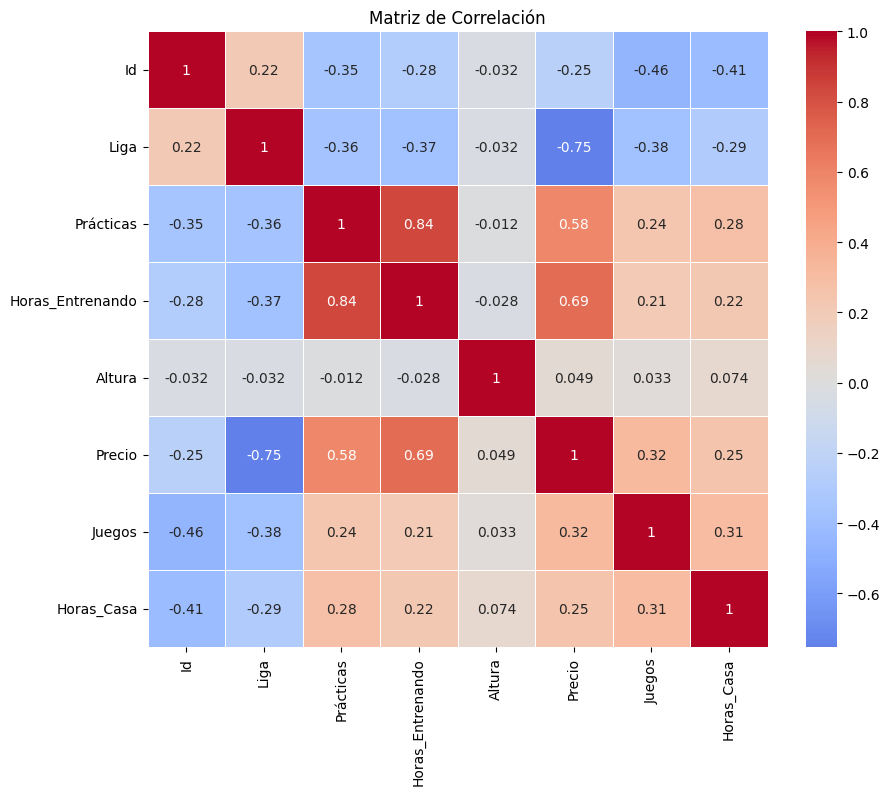

In [89]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=.5)
plt.title("Matriz de Correlación")
plt.show

## Limpieza de datos

Quitar columnas que no necesitamos

In [90]:
df_clean=df.drop(columns=['Nacimiento',"Altura","Nombre","Id", "Horas_Casa"])

In [91]:
df_clean.shape

(400, 8)

## Transformación de datos para Modelo predictivo

### Transformación de variables categóricas


In [92]:
categoricos=df_clean.select_dtypes(include=['object'])
categoricos

,Gimnasio,Fuma,Nutriólogo
0,No,Si,Si
1,Si,No,Si
2,Si,No,Si
3,Si,No,No
4,Si,No,Si
...,...,...,...
395,Si,Si,Si
396,No,Si,No
397,No,No,Si
398,Si,No,No


In [93]:
list_categoricos=list(categoricos)
list_categoricos

['Gimnasio', 'Fuma', 'Nutriólogo']

In [94]:
# Get the dummy variables as a new DataFrame and convert to integer
df_dummies = pd.get_dummies(df_clean[list_categoricos], drop_first=True).astype(int)

# Drop the original categorical columns from df_clean
df_numerical = df_clean.drop(columns=list_categoricos)

# Concatenate the numerical features with the integer dummy variables
df_transf = pd.concat([df_numerical, df_dummies], axis=1)

In [95]:
df_transf=pd.get_dummies(df_clean,columns=list_categoricos,drop_first=True)
df_transf

,Liga,Prácticas,Horas_Entrenando,Precio,Juegos,Gimnasio_Si,Fuma_Si,Nutriólogo_Si
0,1,4,6,4.711956e+05,12,False,True,True
1,1,6,6,7.872461e+05,12,True,False,True
2,1,5,13,1.795484e+06,10,True,False,True
3,1,3,9,9.755637e+05,12,True,False,False
4,1,3,5,4.048235e+05,9,True,False,True
...,...,...,...,...,...,...,...,...
395,3,2,3,6.768828e+04,3,True,True,True
396,3,2,6,6.746402e+04,6,False,True,False
397,3,2,3,5.110220e+04,4,False,False,True
398,3,1,2,5.192207e+04,4,True,False,False


In [96]:
df_transf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Liga              400 non-null    int64  
 1   Prácticas         400 non-null    int64  
 2   Horas_Entrenando  400 non-null    int64  
 3   Precio            400 non-null    float64
 4   Juegos            400 non-null    int64  
 5   Gimnasio_Si       400 non-null    bool   
 6   Fuma_Si           400 non-null    bool   
 7   Nutriólogo_Si     400 non-null    bool   
dtypes: bool(3), float64(1), int64(4)
memory usage: 16.9 KB


In [97]:
# Convertir manualmente la columna "Nacimiento" a datetime
df["Nacimiento"] = pd.to_datetime(df["Nacimiento"])

### Normalización (Estandarización) de datos

In [98]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [99]:
dfScaler=RobustScaler()

In [100]:
scaler = dfScaler.fit(df_transf)

In [101]:
dfScaled=scaler.transform(df_transf)

In [102]:
dfScaled

array([[-1.        ,  0.33333333,  0.        , ..., -1.        ,
         1.        ,  1.        ],
       [-1.        ,  1.        ,  0.        , ...,  0.        ,
         0.        ,  1.        ],
       [-1.        ,  0.66666667,  1.        , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.        , -0.33333333, -0.42857143, ..., -1.        ,
         0.        ,  1.        ],
       [ 1.        , -0.66666667, -0.57142857, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.        , -0.33333333, -0.57142857, ..., -1.        ,
         1.        ,  0.        ]])

Se crea un nuevo dataFrame con los datos normalizados

In [103]:
dfNormal= pd.DataFrame(dfScaled, columns=df_transf.columns)
dfNormal

,Liga,Prácticas,Horas_Entrenando,Precio,Juegos,Gimnasio_Si,Fuma_Si,Nutriólogo_Si
0,-1.0,0.333333,0.000000,-0.153054,1.50,-1.0,1.0,1.0
1,-1.0,1.000000,0.000000,0.316373,1.50,0.0,0.0,1.0
2,-1.0,0.666667,1.000000,1.813901,1.00,0.0,0.0,1.0
3,-1.0,0.000000,0.428571,0.596080,1.50,0.0,0.0,0.0
4,-1.0,0.000000,-0.142857,-0.251636,0.75,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
395,1.0,-0.333333,-0.428571,-0.752381,-0.75,0.0,1.0,1.0
396,1.0,-0.333333,0.000000,-0.752714,0.00,-1.0,1.0,0.0
397,1.0,-0.333333,-0.428571,-0.777016,-0.50,-1.0,0.0,1.0
398,1.0,-0.666667,-0.571429,-0.775798,-0.50,0.0,0.0,0.0


In [104]:
dfNormal.describe()

,Liga,Prácticas,Horas_Entrenando,Precio,Juegos,Gimnasio_Si,Fuma_Si,Nutriólogo_Si
count,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.00000
mean,-0.190000,0.197500,0.198214,1.648559e-01,0.039375,-0.410000,0.330000,0.49250
std,0.946647,0.619595,0.695343,8.151391e-01,0.639779,0.492449,0.470802,0.50057
min,-1.000000,-0.666667,-0.714286,-8.529174e-01,-1.250000,-1.000000,0.000000,0.00000
25%,-1.000000,-0.333333,-0.428571,-3.904869e-01,-0.500000,-1.000000,0.000000,0.00000
50%,0.000000,0.000000,0.000000,8.630249e-17,0.000000,0.000000,0.000000,0.00000
75%,0.000000,0.666667,0.571429,6.095131e-01,0.500000,0.000000,1.000000,1.00000
max,2.000000,2.000000,2.142857,2.947933e+00,1.500000,0.000000,1.000000,1.00000


### Partición de datos

dividir el conjunto de datos de entrenamiento

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
train_val_df, test_df= train_test_split(dfNormal,test_size=0.2,random_state=23)

In [107]:
test_df

,Liga,Prácticas,Horas_Entrenando,Precio,Juegos,Gimnasio_Si,Fuma_Si,Nutriólogo_Si
133,0.0,-0.333333,-0.285714,-0.305494,-0.75,0.0,0.0,0.0
331,1.0,0.333333,0.571429,-0.657685,0.00,-1.0,1.0,0.0
167,0.0,-0.666667,-0.714286,-0.433170,0.50,0.0,0.0,1.0
335,1.0,-0.666667,-0.428571,-0.768951,-0.75,-1.0,0.0,0.0
239,0.0,1.333333,2.142857,0.725638,0.50,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
155,-1.0,1.000000,1.428571,1.589460,-0.25,-1.0,0.0,0.0
74,-1.0,0.666667,0.571429,0.113823,0.75,-1.0,1.0,0.0
270,-1.0,0.000000,-0.285714,-0.001371,0.00,-1.0,0.0,1.0
216,-1.0,-0.333333,-0.142857,0.937693,0.25,0.0,0.0,0.0


In [108]:
X_train, Y_train = train_val_df.drop(columns=["Precio"], axis=1), train_val_df["Precio"]

In [109]:
X_test, Y_test = test_df.drop(columns=["Precio"], axis=1), test_df["Precio"]

In [110]:
Y_test

,Precio
133,-0.305494
331,-0.657685
167,-0.433170
335,-0.768951
239,0.725638
...,...
155,1.589460
74,0.113823
270,-0.001371
216,0.937693


## Modelo Predictivo

In [111]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [112]:
rfr_model = RandomForestRegressor()

In [113]:
rfr_model.fit(X_train, Y_train)

RandomForestRegressor()

In [114]:
y_train_pred = rfr_model.predict(X_train)
y_test_pred = rfr_model.predict(X_test)

In [115]:
y_train_pred

array([ 0.73360925, -0.77270005,  0.956644  , -0.85291744,  1.20219684,
        0.02173743, -0.38026133,  0.55214273, -0.85291744,  0.17465592,
        0.68679894,  1.01418669,  0.27199745,  0.87061705, -0.77604195,
       -0.37769405, -0.23690124,  0.07329572,  0.20018913, -0.77249594,
       -0.75801962, -0.15244031,  0.98698845,  2.7311892 , -0.23598416,
       -0.77179556, -0.20339688, -0.73963865,  0.27985996, -0.77242437,
        0.38726657, -0.1441427 ,  0.17082379, -0.85291744,  1.59612322,
       -0.41249338, -0.30456705, -0.00495855,  0.18669883, -0.74078563,
        0.22097229,  2.60494117,  2.45825055,  0.34783917,  1.0821449 ,
        0.20564481,  0.77776785, -0.85291744,  0.44333301,  0.2813879 ,
       -0.78173152, -0.19737012, -0.77320435, -0.85291744, -0.75360105,
       -0.85291744,  0.13802709,  1.45343362,  0.48189179,  0.45314163,
        0.12189848, -0.39243463, -0.77671232, -0.65960898,  0.61792834,
        0.84778861,  0.38495375,  1.0529544 ,  0.83199405,  0.73

In [116]:
train_mse=mean_squared_error(Y_train,y_train_pred)
test_mse=mean_squared_error(Y_test,y_test_pred)

In [117]:
test_mse

0.11348764314225915

In [118]:
train_mse

0.024017447151966763

In [119]:
train_r2=r2_score(Y_train,y_train_pred)
test_r2=r2_score(Y_test,y_test_pred)

In [120]:
train_r2, test_r2

(0.9633058006596237, 0.8357714764410914)

##Análisis de datos del modelo predictivo

In [121]:
df

,Id,Nombre,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Gimnasio,Fuma,Nacimiento,Nutriólogo,Horas_Casa
0,1,Mario Llanos,1,4,6,1.691695,4.711956e+05,12,No,Si,1998-01-25,Si,8
1,2,Marta Nathal,1,6,6,1.649811,7.872461e+05,12,Si,No,1998-01-23,Si,8
2,3,Howard Sierra,1,5,13,1.835804,1.795484e+06,10,Si,No,1998-01-24,Si,9
3,4,Luna Nava,1,3,9,1.675274,9.755637e+05,12,Si,No,1998-01-08,No,5
4,5,Eugenio Ibarra,1,3,5,1.597647,4.048235e+05,9,Si,No,1998-01-20,Si,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,Gabriel Soberón,3,2,3,1.532822,6.768828e+04,3,Si,Si,1998-12-28,Si,2
396,397,Lily Vera,3,2,6,1.637571,6.746402e+04,6,No,Si,1998-12-13,No,0
397,398,Silvana Córdova,3,2,3,1.578813,5.110220e+04,4,No,No,1998-12-26,Si,2
398,399,Ezequiel Almeda,3,1,2,1.870642,5.192207e+04,4,Si,No,1998-12-26,No,2


## Visualización de datos del modelo predictivo

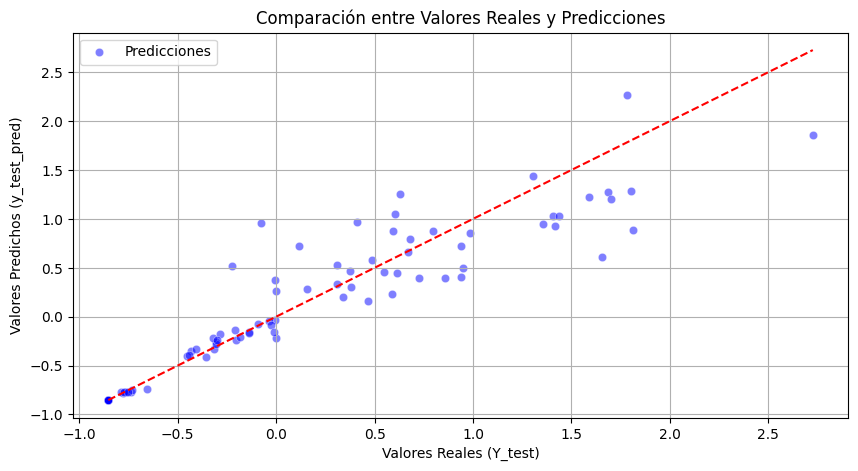

In [122]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=Y_test, y=y_test_pred, color="blue", alpha=0.5, label="Predicciones")
plt.xlabel("Valores Reales (Y_test)")
plt.ylabel("Valores Predichos (y_test_pred)")
plt.title("Comparación entre Valores Reales y Predicciones")
plt.legend()
plt.grid(True)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.show()


## Análisis y visualización del DataSet

In [123]:
df

,Id,Nombre,Liga,Prácticas,Horas_Entrenando,Altura,Precio,Juegos,Gimnasio,Fuma,Nacimiento,Nutriólogo,Horas_Casa
0,1,Mario Llanos,1,4,6,1.691695,4.711956e+05,12,No,Si,1998-01-25,Si,8
1,2,Marta Nathal,1,6,6,1.649811,7.872461e+05,12,Si,No,1998-01-23,Si,8
2,3,Howard Sierra,1,5,13,1.835804,1.795484e+06,10,Si,No,1998-01-24,Si,9
3,4,Luna Nava,1,3,9,1.675274,9.755637e+05,12,Si,No,1998-01-08,No,5
4,5,Eugenio Ibarra,1,3,5,1.597647,4.048235e+05,9,Si,No,1998-01-20,Si,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,Gabriel Soberón,3,2,3,1.532822,6.768828e+04,3,Si,Si,1998-12-28,Si,2
396,397,Lily Vera,3,2,6,1.637571,6.746402e+04,6,No,Si,1998-12-13,No,0
397,398,Silvana Córdova,3,2,3,1.578813,5.110220e+04,4,No,No,1998-12-26,Si,2
398,399,Ezequiel Almeda,3,1,2,1.870642,5.192207e+04,4,Si,No,1998-12-26,No,2


In [124]:
# Promedio de la calidad y duración del sueño
grupo=df.groupby('Liga')[['Fuma']].value_counts()
grupo

Liga  Fuma
1     No      135
      Si       57
2     No       86
      Si       38
3     No       33
      Si       19
4     Si       18
      No       14
Name: count, dtype: int64

In [125]:
grupo = df.groupby('Liga')['Fuma'].value_counts().unstack(fill_value=0)
grupo

Fuma,No,Si
Liga,,
1,135,57
2,86,38
3,33,19
4,14,18


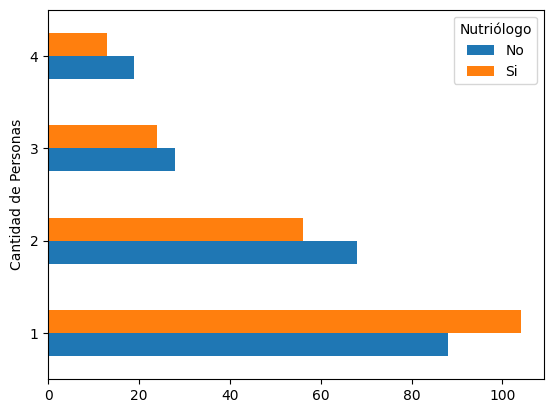

In [143]:
cantidad_personas = df.groupby(["Liga", "Nutriólogo"]).size().unstack()
cantidad_personas.plot.barh()
plt.ylabel("Cantidad de Personas")
plt.show()

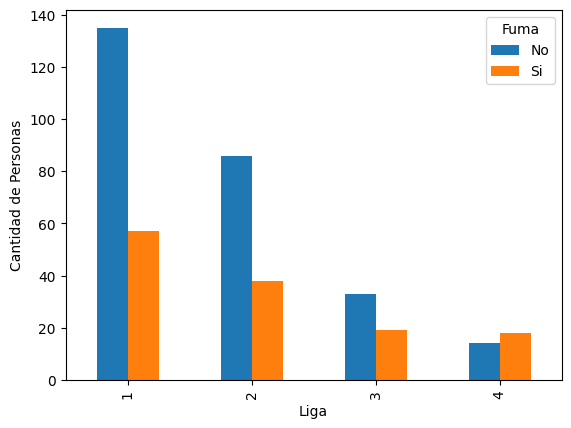

In [127]:
cantidad_personas = df.groupby(["Liga", "Fuma"]).size().unstack()
cantidad_personas.plot.bar()
plt.ylabel("Cantidad de Personas")
plt.show()

In [128]:
grupo = df.groupby('Prácticas')['Fuma'].value_counts().unstack(fill_value=0)
grupo

Fuma,No,Si
Prácticas,,
1,35,15
2,52,30
3,56,26
4,46,22
5,33,17
6,19,14
7,21,4
8,5,3
9,1,1


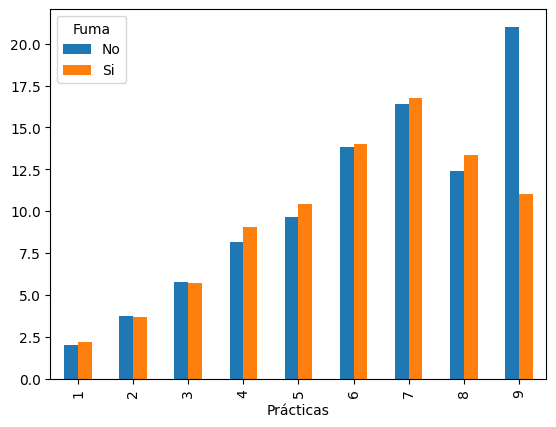

In [129]:
entrenamiento = df.pivot_table(index="Prácticas", columns="Fuma", values="Horas_Entrenando", aggfunc="mean")
entrenamiento.plot.bar()
plt.show()

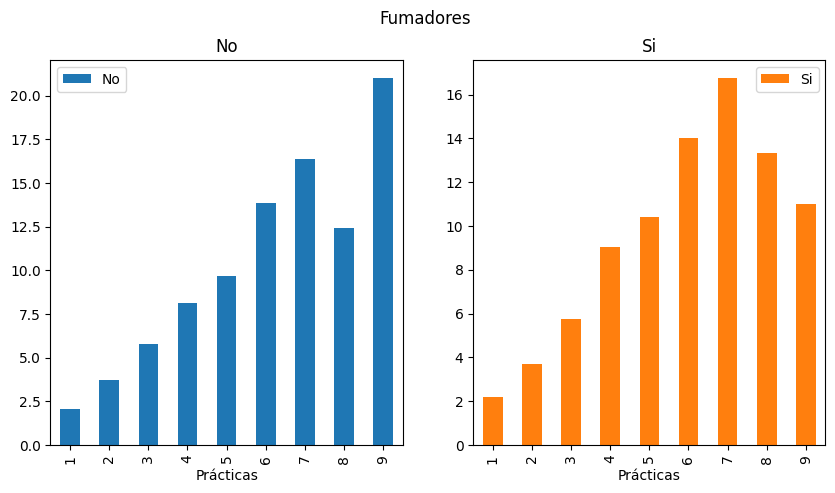

In [130]:
entrenamiento.plot.bar(layout=(1,2), subplots=True, figsize=(10,5))
plt.suptitle("Fumadores")
plt.show()

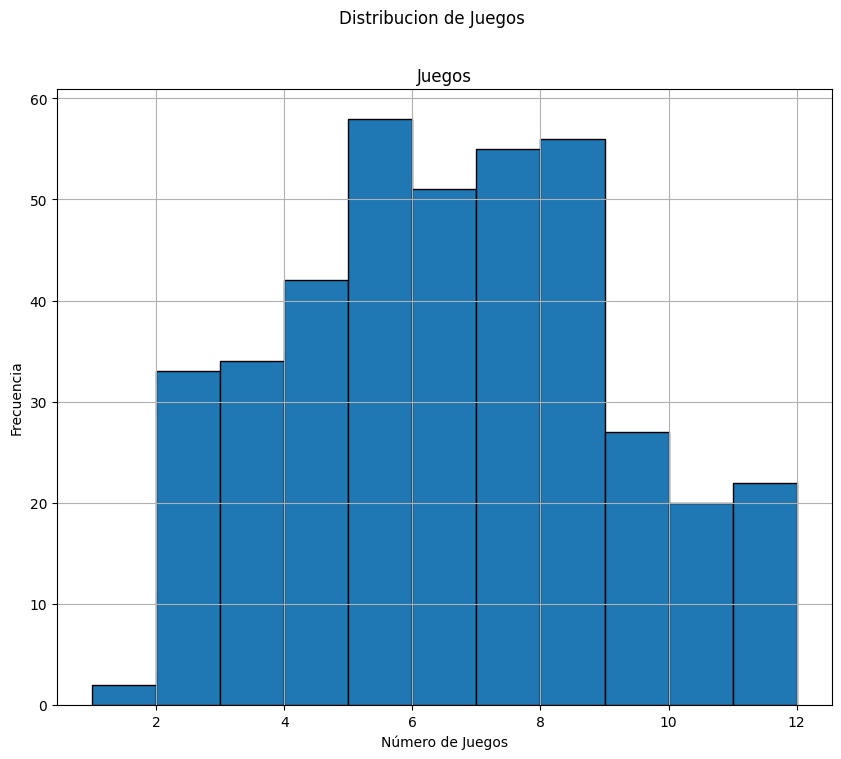

In [131]:

df.hist(column="Juegos", bins=11, edgecolor="black", figsize=(10, 8))
plt.xlabel("Número de Juegos")
plt.ylabel("Frecuencia")
plt.suptitle("Distribucion de Juegos")
plt.show()

In [132]:
df.groupby(by="Liga").size()
df['Liga'].value_counts()

,count
Liga,
1,192
2,124
3,52
4,32


In [133]:
liga_promedio_horas = df.groupby('Liga')['Precio'].mean()
liga_promedio_horas

,Precio
Liga,
1,1.102938e+06
2,4.750923e+05
3,6.573467e+04
4,0.000000e+00


In [134]:
liga_promedio_horas = df.groupby('Liga')['Horas_Casa'].mean()
liga_promedio_horas

,Horas_Casa
Liga,
1,4.427083
2,3.524194
3,2.903846
4,2.343750


In [135]:
liga_promedio_horas = df.groupby('Liga')['Juegos'].mean()
liga_promedio_horas

,Juegos
Liga,
1,7.098958
2,5.588710
3,5.442308
4,3.875000


In [136]:
liga_promedio_horas = df.groupby('Liga')['Prácticas'].mean()
liga_promedio_horas

,Prácticas
Liga,
1,4.213542
2,3.435484
3,2.346154
4,2.500000


In [137]:
liga_promedio_horas = df.groupby('Liga')['Altura'].mean()
liga_promedio_horas

,Altura
Liga,
1,1.705885
2,1.682680
3,1.716470
4,1.685952


In [138]:
liga_promedio_horas = df.groupby('Liga')['Horas_Entrenando'].mean()
liga_promedio_horas

,Horas_Entrenando
Liga,
1,9.166667
2,6.645161
3,4.326923
4,4.562500


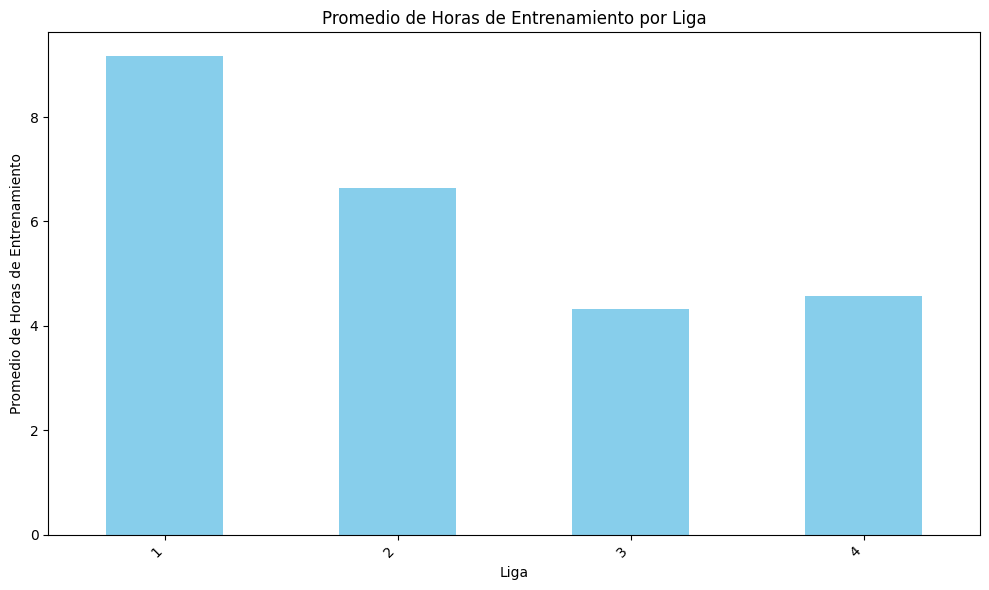

In [139]:
plt.figure(figsize=(10, 6))
liga_promedio_horas.plot(kind='bar', color='skyblue')
plt.title('Promedio de Horas de Entrenamiento por Liga')
plt.xlabel('Liga')
plt.ylabel('Promedio de Horas de Entrenamiento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [140]:
grupo = df.groupby('Prácticas')['Fuma'].value_counts().unstack(fill_value=0)
grupo

Fuma,No,Si
Prácticas,,
1,35,15
2,52,30
3,56,26
4,46,22
5,33,17
6,19,14
7,21,4
8,5,3
9,1,1


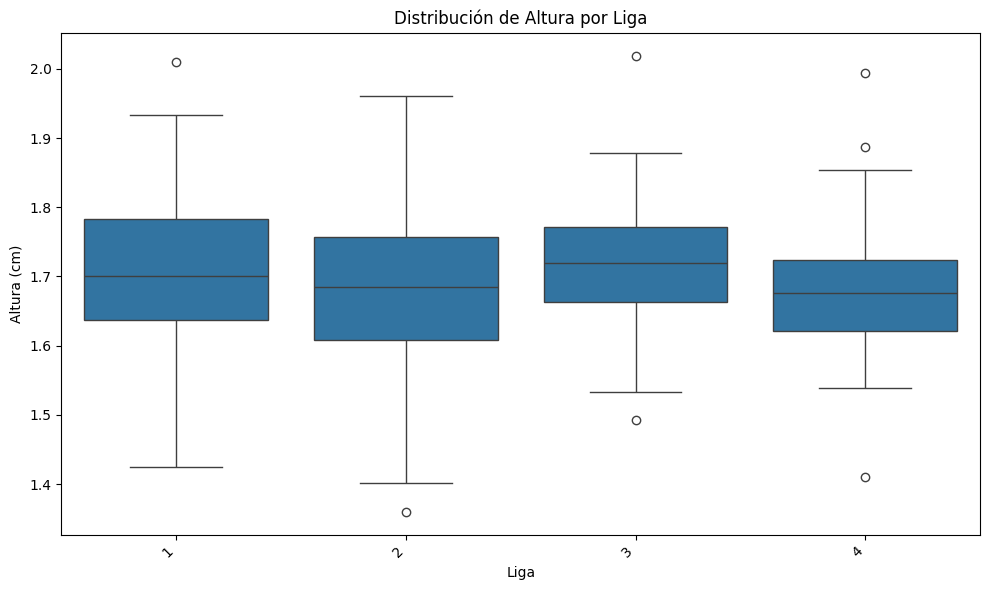

In [141]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Liga', y='Altura', data=df)
plt.title('Distribución de Altura por Liga')
plt.xlabel('Liga')
plt.ylabel('Altura (cm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

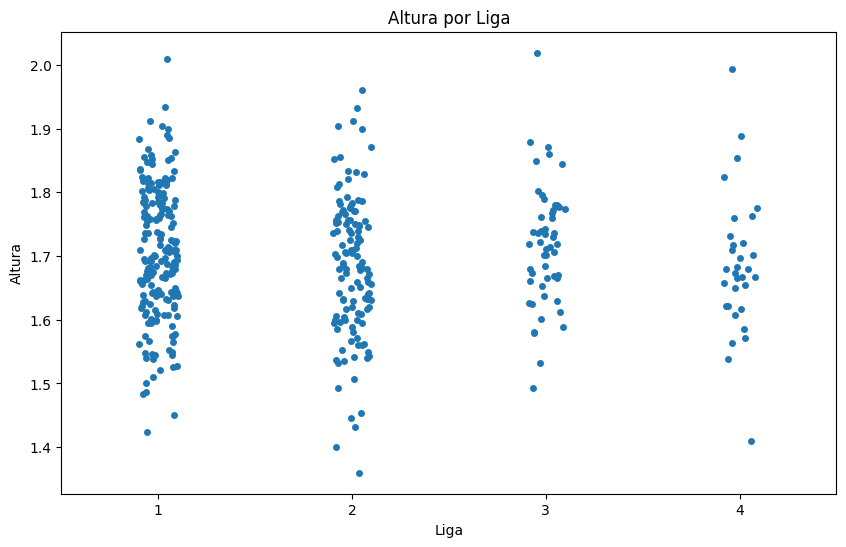

In [142]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x="Liga", y="Altura")
plt.title("Altura por Liga")
plt.xlabel("Liga")
plt.ylabel("Altura")
plt.show()

## Implementación del modelo predictivo